In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("My Drive contents:")
for item in drive_root.iterdir():
    print(item.name)

My Drive contents:
Untitled0.ipynb
Untitled2.ipynb
Untitled1.ipynb
Untitled4.ipynb
Untitled5.ipynb
Untitled6.ipynb
Untitled7.ipynb
Untitled9.ipynb
Untitled10.ipynb
Untitled3.ipynb
IMG-20240218-WA0004.jpg
AI ML Assignment 1, 2, 3, 4, 5 and 7.gdoc
Untitled13.ipynb
Untitled14.ipynb
Screenshot_2024-03-14-21-21-34-992_com.phonepe.app.jpg
20230090.pdf
Untitled (4)
Untitled (3)
Untitled (2)
Untitled (1)
titanic.csv
Untitled11.ipynb
AI & ML assignment 8.txt
AI & ML assignment 10.txt
Untitled12.ipynb
Untitled16.ipynb
Untitled17.ipynb
Untitled18.ipynb
Untitled8.ipynb
Untitled15.ipynb
Untitled
Untitled20.ipynb
Untitled19.ipynb
Untitled21.ipynb
Screenshot_2024-06-13-15-17-10-420_com.android.chrome.jpg
Screenshot_2024-06-19-19-22-19-318_com.android.chrome.jpg
Screenshot_2024-06-19-19-26-41-674_com.android.chrome.jpg
Screenshot_2024-07-20-23-02-36-210_com.miui.gallery-edit.jpg
FirstyrBioTech
Pipelines.ipynb
Untitled22.ipynb
Untitled23.ipynb
20233340assignment3.pdf
Lab1_DeepLearning.ipynb
Untitled24.

In [7]:
data_dir = Path(
    "/content/drive/MyDrive/prismPYP/empiar_10379"
)

print("Dataset folder exists:", data_dir.exists())

print("\nFiles:")
for file in data_dir.iterdir():
    print(file.name)

Dataset folder exists: True

Files:
18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00004en-a.mrc
18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00005en-a.mrc


In [8]:
mrc_files = sorted(data_dir.glob("*.mrc"))

print("Number of MRC files:", len(mrc_files))

for file in mrc_files:
    print("\nFile:", file.name)
    print("Size:", file.stat().st_size, "bytes")

Number of MRC files: 2

File: 18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00004en-a.mrc
Size: 56956944 bytes

File: 18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00005en-a.mrc
Size: 56956944 bytes


In [11]:
!pip install mrcfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.6 MB/s eta 0:00:00


In [12]:
import mrcfile
import numpy as np

mrc_path = mrc_files[0]

with mrcfile.open(mrc_path, permissive=True) as mrc:
    micrograph = np.array(mrc.data)

print("File:", mrc_path.name)
print("Shape:", micrograph.shape)
print("dtype:", micrograph.dtype)
print("Minimum:", micrograph.min())
print("Maximum:", micrograph.max())
print("Mean:", micrograph.mean())
print("Standard deviation:", micrograph.std())

File: 18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00004en-a.mrc
Shape: (3710, 3838)
dtype: float32
Minimum: 0.06223142
Maximum: 46.456543
Mean: 21.40462
Standard deviation: 3.5968223


# Real-Domain SimSiam

Implementation of the real-domain self-supervised learning branch used in the prismPYP reproduction.

The notebook first verifies the SimSiam architecture and forward pass before moving to GPU-based training.

## 1. Setup

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import mrcfile
from pathlib import Path

import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms

In [14]:
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Device: cuda


## 2. Load Micrograph

In [ ]:
data_dir = Path("../data/raw/empiar_10379")
mrc_files = sorted(data_dir.glob("*.mrc"))

mrc_path = mrc_files[0]

with mrcfile.open(mrc_path, permissive=True) as mrc:
    micrograph = np.array(mrc.data)

print("File:", mrc_path.name)
print("Shape:", micrograph.shape)

File: 18sep26a_grid4e_3_00083gr_00001sq_v01_00003hl_00004en-a.mrc
Shape: (3710, 3838)


## 3. Prepare Model Input

The ResNet-50 encoder expects a fixed spatial input size. For the initial implementation, the micrograph is converted to a 224 × 224 tensor.

In [15]:
micrograph_norm = (
    micrograph - micrograph.min()
) / (
    micrograph.max() - micrograph.min()
)

print(
    "Normalized range:",
    micrograph_norm.min(),
    micrograph_norm.max()
)

Normalized range: 0.0 1.0


In [16]:
from PIL import Image

image = Image.fromarray(
    (micrograph_norm * 255).astype(np.uint8)
)

image.size

(3838, 3710)

## 4. Real-Domain Augmentation

SimSiam learns from two augmented views of the same image. The augmentations should change the appearance of the input while preserving the underlying image content.

In [82]:
real_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomRotation(60),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.2
    ),
    transforms.GaussianBlur([0.1, 0.5]),
    transforms.ToTensor(),
])

In [83]:
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

In [18]:
view1 = real_transform(image)
view2 = real_transform(image)

print("View 1:", view1.shape)
print("View 2:", view2.shape)

View 1: torch.Size([1, 224, 224])
View 2: torch.Size([1, 224, 224])


In [20]:
view1 = view1.repeat(3, 1, 1)
view2 = view2.repeat(3, 1, 1)

print("View 1:", view1.shape)
print("View 2:", view2.shape)

View 1: torch.Size([3, 224, 224])
View 2: torch.Size([3, 224, 224])


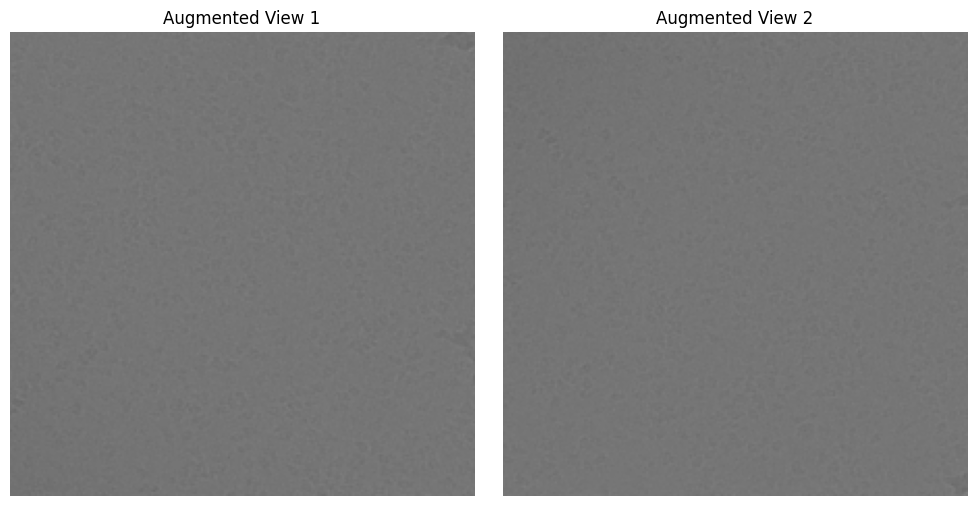

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(view1.permute(1, 2, 0))
axes[0].set_title("Augmented View 1")
axes[0].axis("off")

axes[1].imshow(view2.permute(1, 2, 0))
axes[1].set_title("Augmented View 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. ResNet-50 Encoder

In [22]:
import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [23]:
batch1 = view1.unsqueeze(0).to(device)
batch2 = view2.unsqueeze(0).to(device)

print("Batch 1:", batch1.shape)
print("Batch 2:", batch2.shape)

Batch 1: torch.Size([1, 3, 224, 224])
Batch 2: torch.Size([1, 3, 224, 224])


In [25]:
from torchvision import models

resnet = models.resnet50(weights=None)

# Remove the ImageNet classification layer
encoder = nn.Sequential(
    *list(resnet.children())[:-1]
)

encoder = encoder.to(device)
encoder.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [26]:
with torch.no_grad():
    z = encoder(batch1)

print("Encoder output:", z.shape)

Encoder output: torch.Size([1, 2048, 1, 1])


In [27]:
z = torch.flatten(z, 1)

print("Representation:", z.shape)

Representation: torch.Size([1, 2048])


## 6. Reducer

The encoder produces a 2048-dimensional representation. The reducer maps this representation to a 512-dimensional embedding.

In [61]:
class Reducer(nn.Module):
    def __init__(self, input_dim=2048, output_dim=512):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),

            nn.Linear(1024, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU(inplace=True),

            nn.Linear(output_dim, output_dim),
            nn.BatchNorm1d(output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [62]:
reducer = Reducer().to(device)

In [63]:
reducer.eval()
with torch.no_grad():
    h = reducer(z)

print("Encoder representation:", z.shape)
print("Reduced embedding:", h.shape)

Encoder representation: torch.Size([1, 2048])
Reduced embedding: torch.Size([1, 512])


## 7. Projector

In [64]:
class Projector(nn.Module):
    def __init__(self, input_dim=512, output_dim=512):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim, bias=False),
            nn.BatchNorm1d(input_dim),
            nn.ReLU(inplace=True),

            nn.Linear(input_dim, input_dim, bias=False),
            nn.BatchNorm1d(input_dim),
            nn.ReLU(inplace=True),

            nn.Linear(input_dim, output_dim, bias=False),
            nn.BatchNorm1d(output_dim, affine=False)
        )

    def forward(self, x):
        return self.net(x)

In [65]:
projector = Projector().to(device)

In [66]:
z_dummy = torch.randn(2, 512).to(device)

p = projector(z_dummy)

print("Projector input:", z_dummy.shape)
print("Projector output:", p.shape)

Projector input: torch.Size([2, 512])
Projector output: torch.Size([2, 512])


## 8. Predictor

In [67]:
class Predictor(nn.Module):
    def __init__(self, input_dim=512, hidden_dim=256, output_dim=512):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [68]:
predictor = Predictor().to(device)

In [69]:
p_dummy = torch.randn(2, 512).to(device)

q = predictor(p_dummy)

print("Predictor input:", p_dummy.shape)
print("Predictor output:", q.shape)

Predictor input: torch.Size([2, 512])
Predictor output: torch.Size([2, 512])


## 9. SimSiam Loss

The two augmented views are encouraged to produce similar representations using negative cosine similarity. The target branch is detached from the gradient.

In [70]:
import torch.nn.functional as F

def negative_cosine_similarity(p, z):
    z = z.detach()

    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)

    return -(p * z).sum(dim=1).mean()

In [71]:
p1 = torch.randn(4, 512).to(device)
z2 = torch.randn(4, 512).to(device)

loss = negative_cosine_similarity(p1, z2)

print("Loss:", loss.item())

Loss: 0.007004822604358196


In [72]:
p2 = torch.randn(4, 512).to(device)
z1 = torch.randn(4, 512).to(device)

loss_1 = negative_cosine_similarity(p1, z2)
loss_2 = negative_cosine_similarity(p2, z1)

loss = 0.5 * (loss_1 + loss_2)

print("SimSiam loss:", loss.item())

SimSiam loss: -0.0033842711709439754


## 10. SimSiam Model

Combine the encoder, reducer, projector and predictor into a single model.

In [76]:
class SimSiam(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = models.resnet50(weights=None)

        self.encoder = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        self.reducer = Reducer(
            input_dim=2048,
            output_dim=512
        )

        self.projector = Projector(
            input_dim=512,
            output_dim=512
        )

        self.predictor = Predictor(
            input_dim=512,
            hidden_dim=256,
            output_dim=512
        )

    def forward(self, x):
        # Encoder
        h = self.encoder(x)
        h = torch.flatten(h, 1)

        # Reducer
        h = self.reducer(h)

        # Projector
        z = self.projector(h)

        # Predictor
        p = self.predictor(z)

        return p, z

In [77]:
model = SimSiam().to(device)

print("Model recreated.")

Model recreated.


In [78]:
dummy_input = torch.randn(
    2, 3, 224, 224
).to(device)

In [79]:
model.train()

p1, z1 = model(dummy_input)

print("Predictor output:", p1.shape)
print("Projector output:", z1.shape)

Predictor output: torch.Size([2, 512])
Projector output: torch.Size([2, 512])


In [80]:
print(model)

SimSiam(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64, 

In [46]:
x1 = view1.unsqueeze(0).to(device)
x2 = view2.unsqueeze(0).to(device)

print("x1:", x1.shape)
print("x2:", x2.shape)

x1: torch.Size([1, 3, 224, 224])
x2: torch.Size([1, 3, 224, 224])


In [47]:
images = []

for mrc_path in mrc_files:
    with mrcfile.open(mrc_path, permissive=True) as mrc:
        img = np.array(mrc.data)

    img = (
        img - img.min()
    ) / (
        img.max() - img.min()
    )

    img = Image.fromarray(
        (img * 255).astype(np.uint8)
    )

    images.append(img)

print("Number of images:", len(images))

Number of images: 2


In [48]:
view1_batch = torch.stack([
    real_transform(img) for img in images
])

view2_batch = torch.stack([
    real_transform(img) for img in images
])

print("View 1 batch:", view1_batch.shape)
print("View 2 batch:", view2_batch.shape)

View 1 batch: torch.Size([2, 1, 224, 224])
View 2 batch: torch.Size([2, 1, 224, 224])


In [49]:
view1_batch = view1_batch.repeat(1, 3, 1, 1)
view2_batch = view2_batch.repeat(1, 3, 1, 1)

print("View 1 batch:", view1_batch.shape)
print("View 2 batch:", view2_batch.shape)

View 1 batch: torch.Size([2, 3, 224, 224])
View 2 batch: torch.Size([2, 3, 224, 224])


In [50]:
model.train()

view1_batch = view1_batch.to(device)
view2_batch = view2_batch.to(device)

p1, z1 = model(view1_batch)
p2, z2 = model(view2_batch)

print("p1:", p1.shape)
print("z1:", z1.shape)
print("p2:", p2.shape)
print("z2:", z2.shape)

p1: torch.Size([2, 512])
z1: torch.Size([2, 512])
p2: torch.Size([2, 512])
z2: torch.Size([2, 512])


In [51]:
loss1 = negative_cosine_similarity(p1, z2)
loss2 = negative_cosine_similarity(p2, z1)

loss = 0.5 * (loss1 + loss2)

print("Loss 1:", loss1.item())
print("Loss 2:", loss2.item())
print("Total loss:", loss.item())

Loss 1: 0.045494116842746735
Loss 2: 0.05972091108560562
Total loss: 0.05260751396417618


## 11. Forward and Backward Pass

Before training, verify that the loss can propagate gradients through the model.

In [52]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

optimizer.zero_grad()

loss.backward()

optimizer.step()

print("Backward pass completed successfully.")

Backward pass completed successfully.


## 12. Dataset

Create two augmented views from each micrograph for SimSiam training.

In [53]:
from torch.utils.data import Dataset, DataLoader


class CryoEMDataset(Dataset):
    def __init__(self, mrc_files, transform):
        self.mrc_files = mrc_files
        self.transform = transform

    def __len__(self):
        return len(self.mrc_files)

    def __getitem__(self, idx):
        mrc_path = self.mrc_files[idx]

        with mrcfile.open(mrc_path, permissive=True) as mrc:
            image = np.array(mrc.data)

        # Normalize
        image = (
            image - image.min()
        ) / (
            image.max() - image.min()
        )

        image = Image.fromarray(
            (image * 255).astype(np.uint8)
        )

        view1 = self.transform(image)
        view2 = self.transform(image)

        # Convert grayscale → 3 channels
        view1 = view1.repeat(3, 1, 1)
        view2 = view2.repeat(3, 1, 1)

        return view1, view2

In [54]:
dataset = CryoEMDataset(
    mrc_files=mrc_files,
    transform=real_transform
)

print("Dataset size:", len(dataset))

Dataset size: 2


In [55]:
view1, view2 = dataset[0]

print("View 1:", view1.shape)
print("View 2:", view2.shape)

View 1: torch.Size([3, 224, 224])
View 2: torch.Size([3, 224, 224])


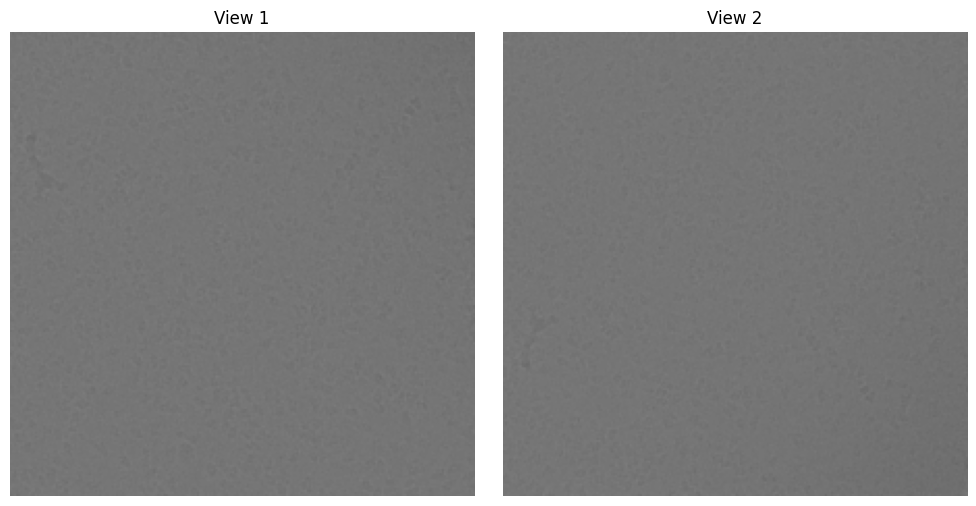

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(view1.permute(1, 2, 0))
axes[0].set_title("View 1")
axes[0].axis("off")

axes[1].imshow(view2.permute(1, 2, 0))
axes[1].set_title("View 2")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 13. DataLoader

In [57]:
batch_size = 2

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

In [58]:
batch_view1, batch_view2 = next(iter(train_loader))

print("Batch view 1:", batch_view1.shape)
print("Batch view 2:", batch_view2.shape)

Batch view 1: torch.Size([2, 3, 224, 224])
Batch view 2: torch.Size([2, 3, 224, 224])


In [59]:
batch_view1 = batch_view1.to(device)
batch_view2 = batch_view2.to(device)

model.train()

p1, z1 = model(batch_view1)
p2, z2 = model(batch_view2)

loss1 = negative_cosine_similarity(p1, z2)
loss2 = negative_cosine_similarity(p2, z1)

loss = 0.5 * (loss1 + loss2)

print("p1:", p1.shape)
print("z1:", z1.shape)
print("p2:", p2.shape)
print("z2:", z2.shape)
print("Loss:", loss.item())

p1: torch.Size([2, 512])
z1: torch.Size([2, 512])
p2: torch.Size([2, 512])
z2: torch.Size([2, 512])
Loss: 0.002900424413383007


In [60]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

optimizer.zero_grad()

loss.backward()

optimizer.step()

print("One training step completed.")

One training step completed.
